In [1]:
import sys
from pathlib import Path

# Add parent directory (where utility.py lives) to the path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

from utility import GroupwisePLSTransformer, _feature_engineering, setpoint_df, ewm_reset

from config import CONTROL_VARS
from data_cleaning import (
    unique_in_order, ordered_difference, ordered_intersection,
    outlier, make_design,
)
from preprocessing import make_prep_pip

sns.set(rc={"figure.figsize": (12, 4)})
sns.set_style("whitegrid")
sns.set_context("notebook")

In [ ]:
Y_COLUMN = "Steam__kWh/T_"
DATA_PATH = "../data/costimier_turnup.parquet"

TIME_AWARE = True
USE_HOLDOUT = True
APPLY_EWM_FILTER = True
DEMEAN_BY_GRAMMAGE = False

TEST_SIZE = 0.20
RANDOM_STATE = 42
N_SPLITS = 5
LAGS = 0

PIPELINE_PREFIXES = ["exha_mois", "inlet_temp", "linepressure", "fabric_tension", "gas_decu"]

BLACK_LIST = [
    "Current_basis_weight", "Bentonite_1_mass_flow__g/T_",
    "Bentonite_2_mass_flow__g/T_", "DG3_Moisture_content_Outlet_Air",
    "Lip_settings", "Conductivity_white_water_B46",
    "pH-Messung_Verd\u00fcnnungswasser__2..12_pH_",
    "pH_measurement_white_water_B41", 
    "CO2_mass_flow__g/T_",
]

CREATED_VARIABLE_CANDIDATES = [
    "Water_Predryer", "diluted_starch", "Fibre__g/m2_",
    "Water_Afterdryer_output", "dewatering",
    "Production_Rate__T/h_", "fibre_short/long",
    "Starch_uptake__g/m2_"
]

In [13]:
# Build PLS preprocessing pipeline
prep_pip, prep_s_vars = make_prep_pip(prefixes=PIPELINE_PREFIXES)

# Load raw data
turnup_data = pd.read_parquet(DATA_PATH)

# Get control variables for the target (excluding vacuum)
ctl_vars = unique_in_order(
    v for v in CONTROL_VARS[Y_COLUMN] if "vacuum" not in v.lower()
)

# Derived variables are created inside build_pre_estimator via FeatureCreator
created_vars = ordered_intersection(CREATED_VARIABLE_CANDIDATES, ctl_vars)

# Feature engineering
turnup_data = _feature_engineering(turnup_data, setpoint_df, steam_null=False, clip=False)
turnup_data = turnup_data.set_index("Wedge_Time").sort_index()

# Time-based filtering
turnup_data = turnup_data[turnup_data.index > "2025-11-1"]
#turnup_data = turnup_data[turnup_data.index > "2026-3-1"]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-24 07:00") & (turnup_data.index < "2026-01-26 10:00"))]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-11 12:00") & (turnup_data.index < "2026-01-12 11:00"))]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-17 12:00") & (turnup_data.index < "2026-01-19 11:00"))]
#turnup_data = turnup_data[turnup_data.index < "2026-07-5"]


# Physical-constraint filtering
turnup_data = turnup_data[
    #(turnup_data["Condensate_energy_from_paper_plant_to_power_plant"].between(5, 10))
    #& 
    (turnup_data["DG4_Temperature_Inlet_Air"] > 100)
    & 
    (turnup_data["Vacuum_Zone_1_PickUp"] < -0.5)
]

#turnup_data = turnup_data[turnup_data[]]

print(f"Filtered data shape: {turnup_data.shape}")

Filtered data shape: (4484, 522)


In [14]:
import re
from preprocessing import build_pre_estimator

# Determine fixed features (always included in CMA-ES)
fixed_features = [
    #"Water_Afterdryer_output",
    "Starch_uptake__g/m2_",
    "ambient_temp_C",
    
    #"ambient_temp_C", "exha_mois_1", "exha_mois_2",
    #"inlet_temp_1", "inlet_temp_2", 
    "linepressure_1",
    #"fabric_tension_1", "gas_decu_1", "gas_decu_2", "gas_decu_3",
    "grammage",
]

# Build reduced candidate variable list (desired output features)
steam_pressure = [v for v in turnup_data.columns if re.search(r"cylinder.*steam_pressure", v, re.I)]
steam_diff_pressure = [v for v in turnup_data.columns if re.search(r"cylinder.*differential_pressure", v, re.I)]

exog_vars_reduced = [
    v for v in ctl_vars
    if (v not in BLACK_LIST and v not in created_vars
        and v not in steam_pressure and v not in steam_diff_pressure
        and "vacuum" not in v.lower())
]
exog_vars_reduced = unique_in_order(fixed_features + exog_vars_reduced + ["grammage"])

# Replace PLS source columns with their transformed scores
for _, step in prep_pip.steps:
    if isinstance(step, GroupwisePLSTransformer):
        transformed_names = [f"{step.score_prefix}_{i}" for i in range(1, step.n_components + 1)]
        exog_vars_reduced = ordered_difference(
            unique_in_order(exog_vars_reduced + transformed_names),
            list(step.pls_columns),
        )

exog_vars_reduced = unique_in_order(fixed_features + exog_vars_reduced)
#APPLY_EWM_FILTER = False
# Build pipeline: FeatureCreator -> (EWM) -> PLS -> Filter -> Scaler/Encoder
pre_estimator, feat_list = build_pre_estimator(
    exog_vars_reduced=exog_vars_reduced,
    prep_pip=prep_pip,
    created_vars=created_vars,
    apply_ewm=APPLY_EWM_FILTER,
)

print(f"Pipeline input columns ({len(feat_list)}): {feat_list}")
print(f"Pipeline output features: {exog_vars_reduced}")

Pipeline input columns (65): ['ambient_temp_C', 'Draw_PS-PD1', 'Moisture_out_of_PreDryer', 'Draw_WS-PS', 'PickUp_Tension', 'Dewatering_top_wire_suction_box_zone_2', 'White_water_temperature', 'Top_wire_tenstion', 'Jet/wire_ratio', 'Top_Felt_Tension', 'Bottom_wire_tension', 'Bottom_Felt_Tension', 'Air_pressure_of_rod_clamping_hose_Top_Roll', 'Airturn_pillow_pressure', 'Dewatering_Suction_Press_Roll', 'Dewatering_First_Press_Roll', 'Steam_temperature_for_PM', 'Steam_pressure_for_PM', 'Dewatering_Shoe_press', 'Total_Dewatering_Press', 'Uhle_box_1_flow___l/min_', 'Stock_deculator_temperature', 'Stock_deculator_pressure', 'Inlet_Air_2_Temperature', 'Inlet_Air_1_Temperature', 'DG1_Ventilator_Revolution_Output', 'DG2_Ventilator_Revolution_Output', 'DG3_Ventilator_Revolution_Output', 'retention', 'Web_tension_AD6', 'AD7_fabric_tension_bottom', 'Act_Deaerator_mass_flow__g/T_', 'Retention_Aid_mass_flow__g/T_', 'Natriumhydroxide_mass_flow__g/T_', 'Fixative_2_mass_flow__g/T_', 'grammage', 'DG1_Moi

In [15]:
# Prepare time series subset
turnup_ts = turnup_data.copy().sort_index()
turnup_ts = turnup_ts[turnup_ts.grammage.isin([115, 120, 100,  90,  85, 110])]

#turnup_ts = turnup_ts.loc[~outlier(turnup_ts[Y_COLUMN], option="PctClip")].copy()

# Chronological split point (fit pipeline on train portion only)
n_samples = len(turnup_ts)
split = int(n_samples * (1.0 - TEST_SIZE))

# Fit pipeline on training rows, transform entire series
ts_raw = turnup_ts.loc[:, feat_list]
pre_estimator.fit(ts_raw.iloc[:split], turnup_ts[Y_COLUMN].iloc[:split])
ts_transformed = pre_estimator.transform(ts_raw)
ts_transformed[Y_COLUMN] = turnup_ts[Y_COLUMN].values
ts_transformed["AB_Grade_ID"] = turnup_ts["AB_Grade_ID"].values

grade_change = turnup_ts["AB_Grade_ID"].ne(turnup_ts["AB_Grade_ID"].shift())
gap12 = turnup_ts.index.to_series().diff().gt(pd.Timedelta("12h")).fillna(True)
ts_transformed["run"] = (grade_change | gap12).cumsum()
ts_transformed = (
    ts_transformed
    .groupby("run")
    .agg(
        {
            **{c: "mean" for c in ts_transformed.columns
               if c not in ["run", "AB_Grade_ID"]},
            "AB_Grade_ID": "first"
        }
    )
    .reset_index()
)


<Axes: xlabel='run', ylabel='Steam__kWh/T_'>

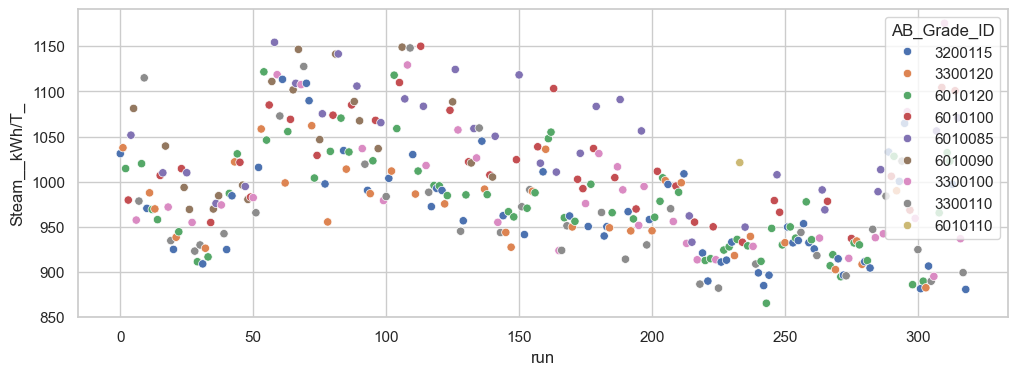

In [16]:
sns.scatterplot(ts_transformed, x="run",y=Y_COLUMN, hue="AB_Grade_ID")

<Axes: xlabel='run', ylabel='Steam__kWh/T_'>

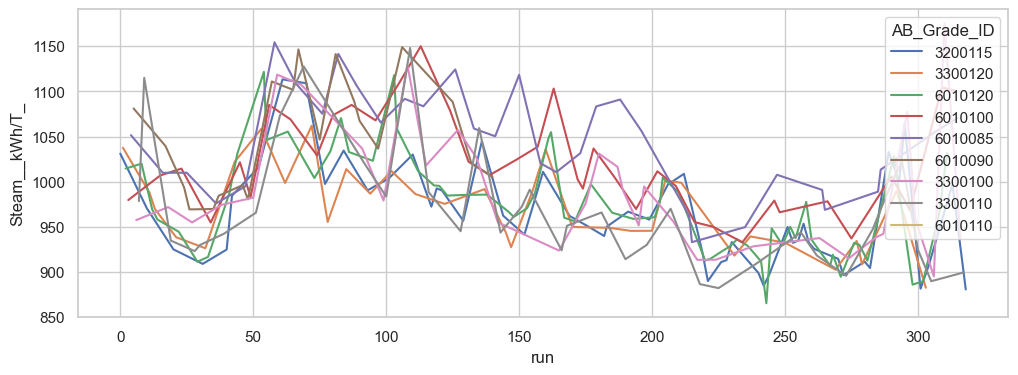

In [6]:
sns.lineplot(ts_transformed, x="run",y=Y_COLUMN, hue="AB_Grade_ID")

## 1. Run-Level Aggregation

Collapse from timestep-level to one row per run. Each run is a contiguous period
of the same grade without time gaps > 12h.

In [7]:
# Aggregate target by run from original data (not pipeline output)
run_labels = ts_transformed['run'].values

y_run_series = pd.Series(
    turnup_ts[Y_COLUMN].values[:len(ts_transformed)],
    index=ts_transformed.index,
)
y_run_agg = y_run_series.groupby(run_labels).mean()

# Deduplicate features: keep one row per run (already run-means)
run_df = ts_transformed.drop(columns=['run']).groupby(run_labels).first()

# Use midpoint timestamp of each run as the index
run_timestamps = turnup_ts.index.to_series().groupby(run_labels).apply(
    lambda g: g.iloc[len(g)//2]
)
run_df.index = run_timestamps.values
run_df.index.name = 'time'
y_run_agg.index = run_timestamps.values

# Separate features and target
feature_cols = [c for c in run_df.columns if c != Y_COLUMN]
X_run = run_df[feature_cols]
y_run = y_run_agg

print(f'Run-level data: {X_run.shape[0]} runs, {X_run.shape[1]} features')
print(f'Target range: [{y_run.min():.1f}, {y_run.max():.1f}]')
print(f'Time range: {X_run.index[0]} to {X_run.index[-1]}')

Run-level data: 319 runs, 51 features
Target range: [890.1, 1159.7]
Time range: 2025-11-16 10:38:30 to 2025-11-30 04:34:30


## 2. Train/Test Split (chronological)

In [ ]:
# Chronological split at run level
n_runs = len(X_run)
split_run = int(n_runs * (1.0 - TEST_SIZE))

Xtr_run = X_run.iloc[:split_run]
Xte_run = X_run.iloc[split_run:]
ytr_run = y_run.iloc[:split_run]
yte_run = y_run.iloc[split_run:]

print(f'Train: {Xtr_run.shape[0]} runs, Test: {Xte_run.shape[0]} runs')

NameError: name 'X' is not defined

## 3. Estimate Level (grade-demeaned)

Remove the grade mean first so that the LocalLevel only captures
slow drift common across all grades — not grade-to-grade jumps.

Grades found: 9 in train
Level scale: 19.1818
Obs noise scale: 24.7760


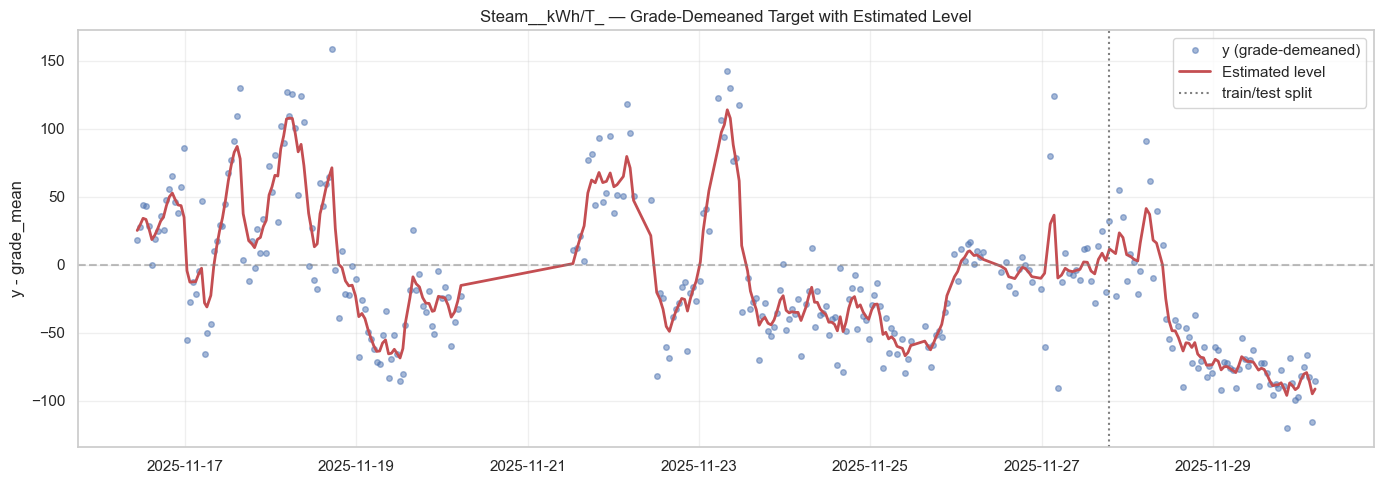

In [9]:
from state_estimation import ResidualStateEstimator

# Get AB_Grade_ID per run from original data
run_labels = (grade_change | gap12).cumsum()
run_grade_id = turnup_ts['AB_Grade_ID'].groupby(run_labels).first().values

# Compute grade means from training portion only (no leakage)
grade_means_train = y_run.iloc[:split_run].groupby(run_grade_id[:split_run]).mean()

# Map grade means to full series (unseen grades in test get NaN -> fill with global mean)
grade_mean_full = pd.Series(run_grade_id, index=y_run.index).map(grade_means_train)
grade_mean_full = grade_mean_full.fillna(y_run.iloc[:split_run].mean())

# Demean: remove grade effect
y_demeaned = y_run - grade_mean_full

# Fit LocalLevel + trend on demeaned target (train only)
state_est_raw = ResidualStateEstimator(level=True, trend=True)
state_result_raw = state_est_raw.fit(y_demeaned.iloc[:split_run])

# Extend to test
state_result_full = state_est_raw.update(y_demeaned.iloc[split_run:])
level_from_y = state_result_full.level

print(f'Grades found: {len(grade_means_train)} in train')
print(f'Level scale: {state_result_raw.level_scale:.4f}')
print(f'Obs noise scale: {state_result_raw.observation_noise_scale:.4f}')

# Plot: demeaned target with estimated level
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_demeaned.index, y_demeaned.values, 'o', ms=4, alpha=0.5, label='y (grade-demeaned)')
ax.plot(level_from_y.index, level_from_y.values, 'r-', lw=2, label='Estimated level')
ax.axvline(ytr_run.index[-1], ls=':', color='gray', label='train/test split')
ax.axhline(0, ls='--', color='gray', alpha=0.5)
ax.set_title(f'{Y_COLUMN} — Grade-Demeaned Target with Estimated Level')
ax.set_ylabel('y - grade_mean'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. De-trend Target

$y^*_r = \bar{y}_r - \hat{s}_r$ — Ridge sees only the within-level variation.

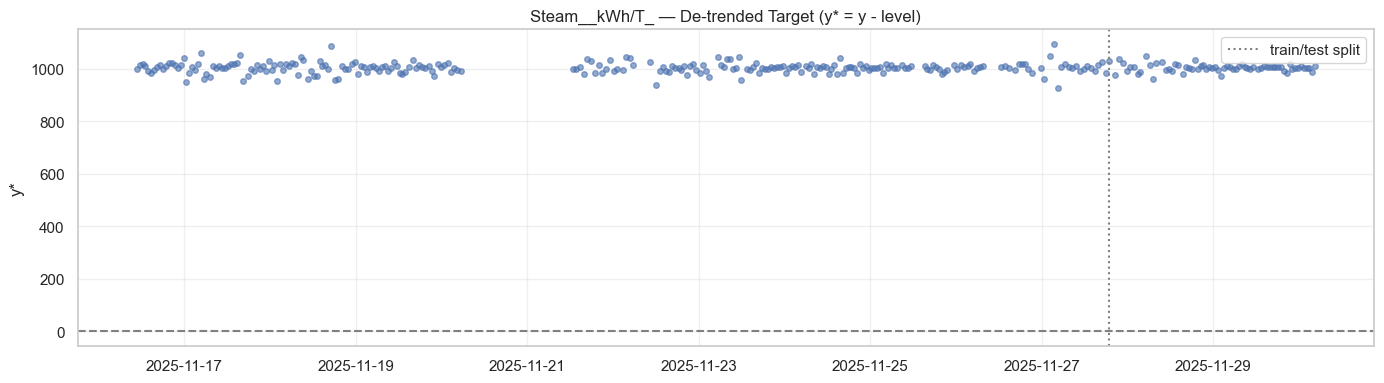

Original y std: 56.21
Adjusted y* std: 19.34


In [10]:
# Subtract level from target
y_adjusted = y_run - level_from_y.values
ytr_adjusted = y_adjusted.iloc[:split_run]
yte_adjusted = y_adjusted.iloc[split_run:]

# Plot adjusted target (should look stationary)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_adjusted.index, y_adjusted.values, 'o', ms=4, alpha=0.6)
ax.axhline(0, ls='--', color='gray')
ax.axvline(ytr_run.index[-1], ls=':', color='gray', label='train/test split')
ax.set_title(f'{Y_COLUMN} — De-trended Target (y* = y - level)')
ax.set_ylabel('y*'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Original y std: {y_run.std():.2f}')
print(f'Adjusted y* std: {y_adjusted.std():.2f}')

## 5. Run-Level Regression on De-trended Target

Fit Ridge on $(\bar{X}_r, y^*_r)$ — process conditions vs de-trended steam.

In [11]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Ridge with alpha tuning
ridge_cv = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())]),
    param_grid={'ridge__alpha': np.logspace(0, 3, 20)},
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error',
    refit=True,
)
ridge_cv.fit(Xtr_run.values, ytr_adjusted.values)

# Predictions (on de-trended scale)
y_train_pred_adj = ridge_cv.predict(Xtr_run.values)
y_test_pred_adj = ridge_cv.predict(Xte_run.values)

# Metrics on de-trended scale
rmse_adj = np.sqrt(mean_squared_error(yte_adjusted, y_test_pred_adj))
r2_adj = r2_score(yte_adjusted, y_test_pred_adj)

print(f'Best alpha: {ridge_cv.best_params_["ridge__alpha"]:.2f}')
print(f'Test RMSE (de-trended): {rmse_adj:.2f}, R2: {r2_adj:.4f}')

Best alpha: 1000.00
Test RMSE (de-trended): 13.95, R2: 0.0358


## 6. Combined Prediction (original scale)

$\hat{y}_r = \hat{f}(\bar{X}_r) + \hat{s}_r$

Add the level back to get predictions on the original scale.

In [27]:
# Restore to original scale: Ridge(adjusted) + level
# (Ridge already captures grade effect via one-hot features)
level_test = level_from_y.iloc[-len(yte_run):].values
y_test_pred = y_test_pred_adj + level_test

# Metrics on original scale
rmse_orig = np.sqrt(mean_squared_error(yte_run, y_test_pred))
r2_orig = r2_score(yte_run, y_test_pred)
mae_orig = mean_absolute_error(yte_run, y_test_pred)

print(f'Test RMSE (original scale): {rmse_orig:.2f}')
print(f'Test MAE:  {mae_orig:.2f}')
print(f'Test R2:   {r2_orig:.4f}')

Test RMSE (original scale): 13.95
Test MAE:  9.70
Test R2:   0.8940


## 7. Re-estimate Level from Regression Residuals

After Ridge explains what it can, fit a fresh LocalLevel on the
residuals $r_r = \bar{y}_r - \hat{f}(\bar{X}_r)$ for a refined state estimate.

In [28]:
# Residuals from original target after reconstruction
y_full_pred_adj = ridge_cv.predict(X_run.values)
level_full_vals = level_from_y.values
y_full_reconstructed = y_full_pred_adj + level_full_vals
residuals_run = y_run.values - y_full_reconstructed
residuals_series = pd.Series(residuals_run, index=y_run.index)

# Fit refined LocalLevel on train residuals
residuals_train = residuals_series.iloc[:split_run]
residuals_test = residuals_series.iloc[split_run:]

state_est_refined = ResidualStateEstimator(level=True, trend=False)
state_result_refined = state_est_refined.fit(residuals_train)
state_result_refined_full = state_est_refined.update(residuals_test)

level_refined_test = state_result_refined_full.level.iloc[-len(yte_run):].values

# Final: Ridge + level + refined level
y_test_final = y_test_pred + level_refined_test

rmse_final = np.sqrt(mean_squared_error(yte_run, y_test_final))
r2_final = r2_score(yte_run, y_test_final)

print(f'Ridge + Level:           RMSE={rmse_orig:.2f}, R2={r2_orig:.4f}')
print(f'Ridge + Level (refined): RMSE={rmse_final:.2f}, R2={r2_final:.4f}')
print(f'Refined level scale: {state_result_refined.level_scale:.4f}')

Ridge + Level:           RMSE=13.95, R2=0.8940
Ridge + Level (refined): RMSE=13.94, R2=0.8941
Refined level scale: 0.0000


## 8. Visualisation

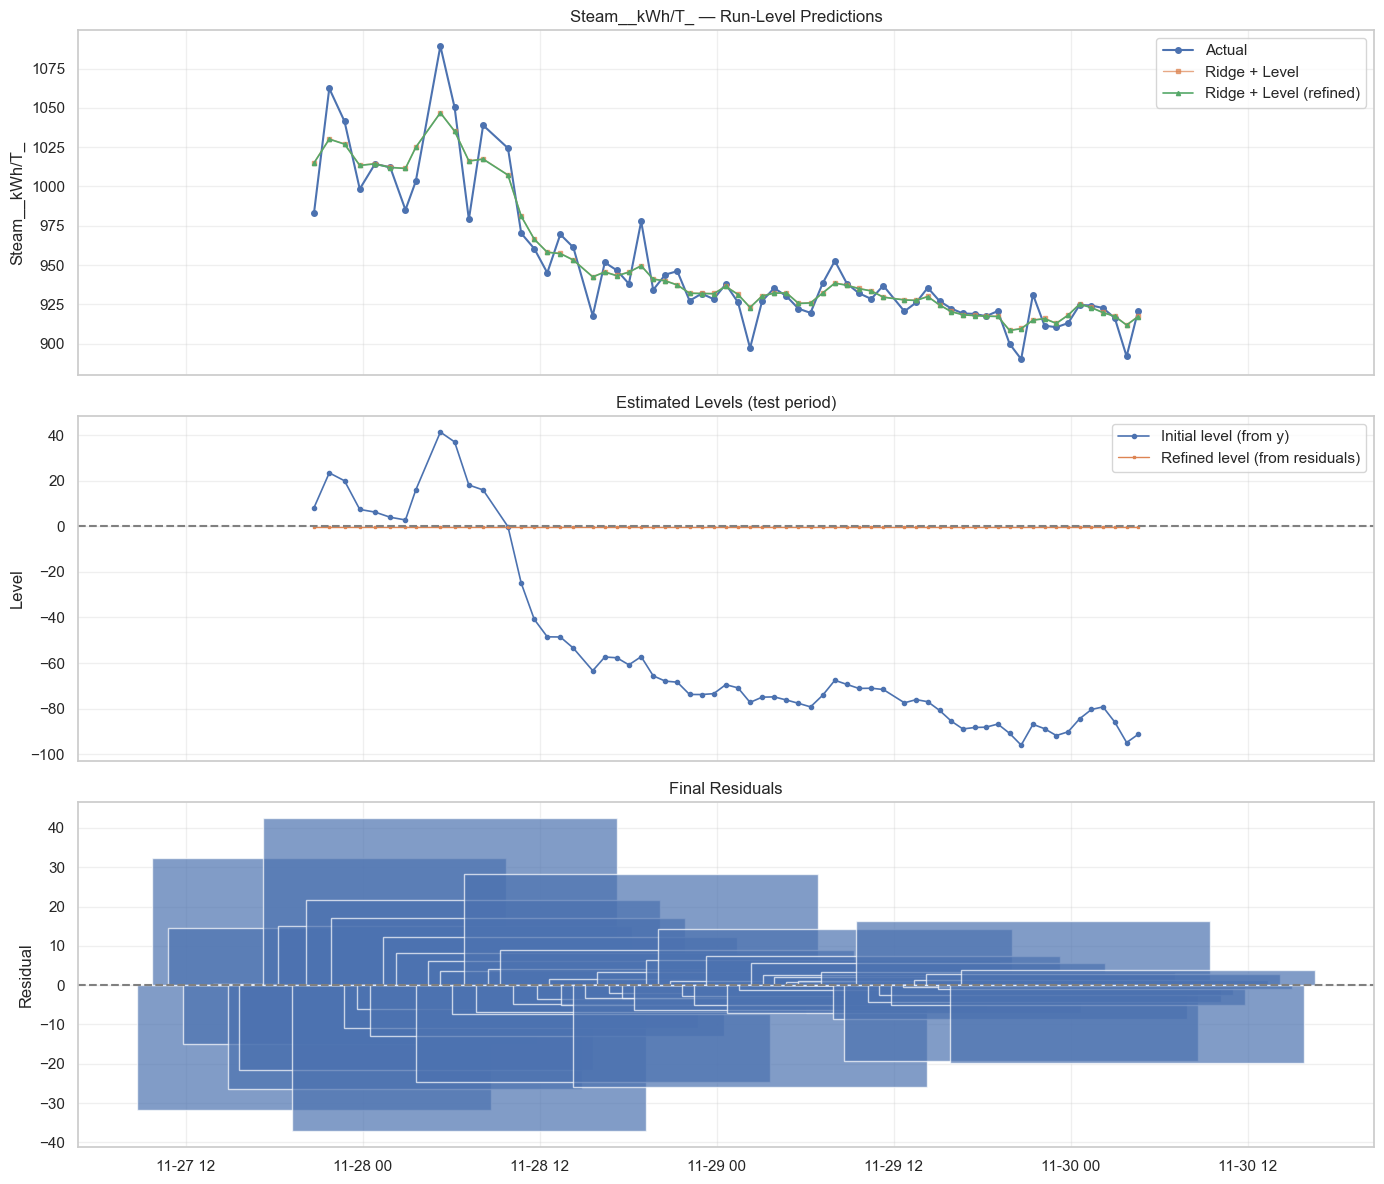

In [29]:
n_test = len(yte_run)
test_idx = yte_run.index

# Align level slices to test period
level_initial_test = level_from_y.iloc[-n_test:].values
level_refined_test_vals = state_result_refined_full.level.iloc[-n_test:].values

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Predictions vs actual
axes[0].plot(test_idx, yte_run.values, 'o-', ms=4, label='Actual', lw=1.5)
axes[0].plot(test_idx, y_test_pred, 's-', ms=3, label='Ridge + Level', lw=1.0, alpha=0.7)
axes[0].plot(test_idx, y_test_final, '^-', ms=3, label='Ridge + Level (refined)', lw=1.2)
axes[0].set_title(f'{Y_COLUMN} — Run-Level Predictions')
axes[0].set_ylabel(Y_COLUMN); axes[0].legend(); axes[0].grid(alpha=0.3)

# Levels (test portion only)
axes[1].plot(test_idx, level_initial_test, 'o-', ms=3, lw=1.2, label='Initial level (from y)')
axes[1].plot(test_idx, level_refined_test_vals, 's-', ms=2, lw=1.0, label='Refined level (from residuals)')
axes[1].axhline(0, ls='--', color='gray')
axes[1].set_title('Estimated Levels (test period)')
axes[1].set_ylabel('Level'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Final residuals
final_resid = yte_run.values - y_test_final
axes[2].bar(test_idx, final_resid, width=1, alpha=0.7)
axes[2].axhline(0, ls='--', color='gray')
axes[2].set_title('Final Residuals')
axes[2].set_ylabel('Residual'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

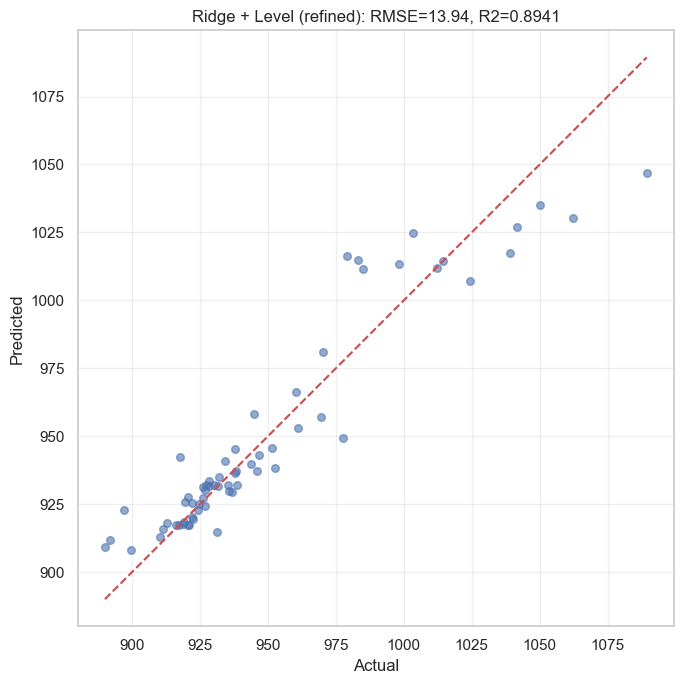

In [30]:
# Scatter: actual vs predicted
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(yte_run.values, y_test_final, alpha=0.6, s=30)
lims = [min(yte_run.min(), y_test_final.min()), max(yte_run.max(), y_test_final.max())]
ax.plot(lims, lims, 'r--', lw=1.5)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title(f'Ridge + Level (refined): RMSE={rmse_final:.2f}, R2={r2_final:.4f}')
ax.set_aspect('equal', adjustable='box'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Decomposition: Regression vs Level Contribution

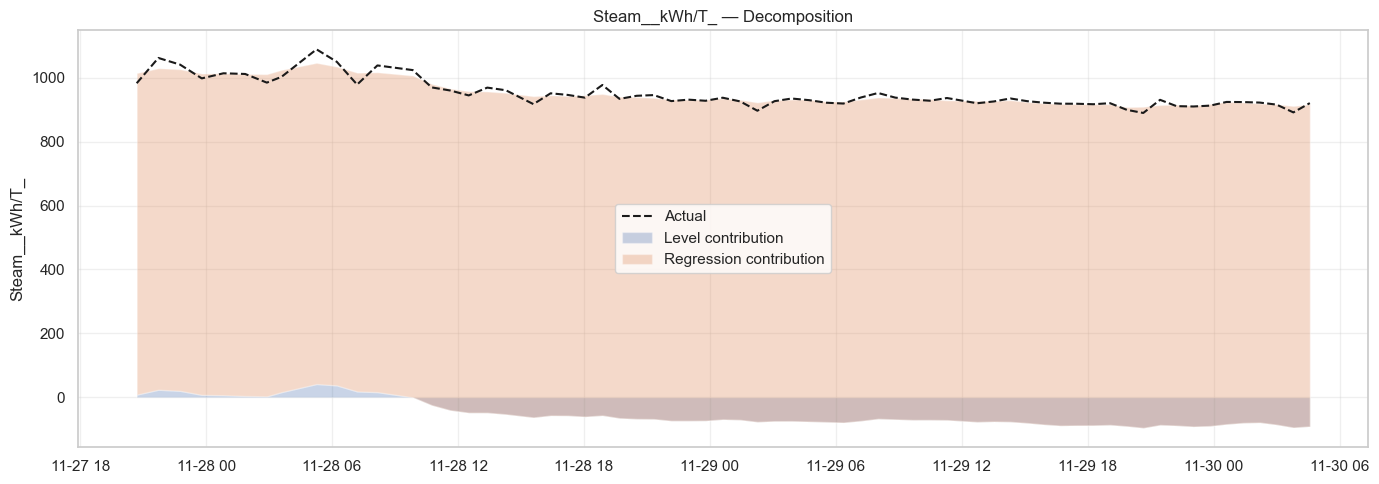

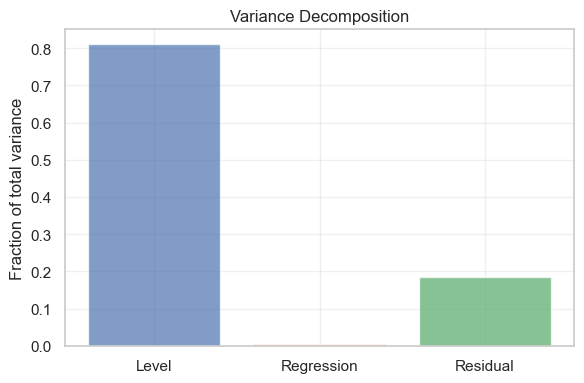

In [31]:
# Decompose: y = Ridge_pred + level + residual
n_test = len(yte_run)
test_idx = yte_run.index

regression_contribution = y_test_pred_adj  # what Ridge explains (de-trended scale)
level_contribution = level_from_y.iloc[-n_test:].values  # what the level explains

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_idx, yte_run.values, 'k--', lw=1.5, label='Actual', zorder=10)
ax.fill_between(test_idx, 0, level_contribution, alpha=0.3, label='Level contribution')
ax.fill_between(test_idx, level_contribution, level_contribution + regression_contribution,
                alpha=0.3, label='Regression contribution')
ax.set_title(f'{Y_COLUMN} — Decomposition')
ax.set_ylabel(Y_COLUMN); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Variance bar chart (separate figure)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Level', 'Regression', 'Residual'],
       [level_var/total_var, reg_var/total_var, 1 - (level_var+reg_var)/total_var],
       color=['C0', 'C1', 'C2'], alpha=0.7)
ax.set_ylabel('Fraction of total variance')
ax.set_title('Variance Decomposition')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 10. SHAP Values for Regression Component

In [ ]:
import shap

# SHAP explainer on the Ridge pipeline (scaler + ridge)
# Background: training data
# Ensure numeric only
X_background = pd.DataFrame(Xtr_run.values, columns=feature_cols).select_dtypes(include=[np.number])
X_explain = pd.DataFrame(Xte_run.values, columns=feature_cols).select_dtypes(include=[np.number])

# Or explicitly convert
X_background = pd.DataFrame(Xtr_run.values, columns=feature_cols).apply(pd.to_numeric, errors='coerce').fillna(0)
X_explain = pd.DataFrame(Xte_run.values, columns=feature_cols).apply(pd.to_numeric, errors='coerce').fillna(0)

explainer = shap.Explainer(ridge_cv.predict, X_background)
shap_values = explainer(X_explain)

print(f'SHAP values shape: {shap_values.values.shape}')
print(f'Features: {len(feature_cols)}')

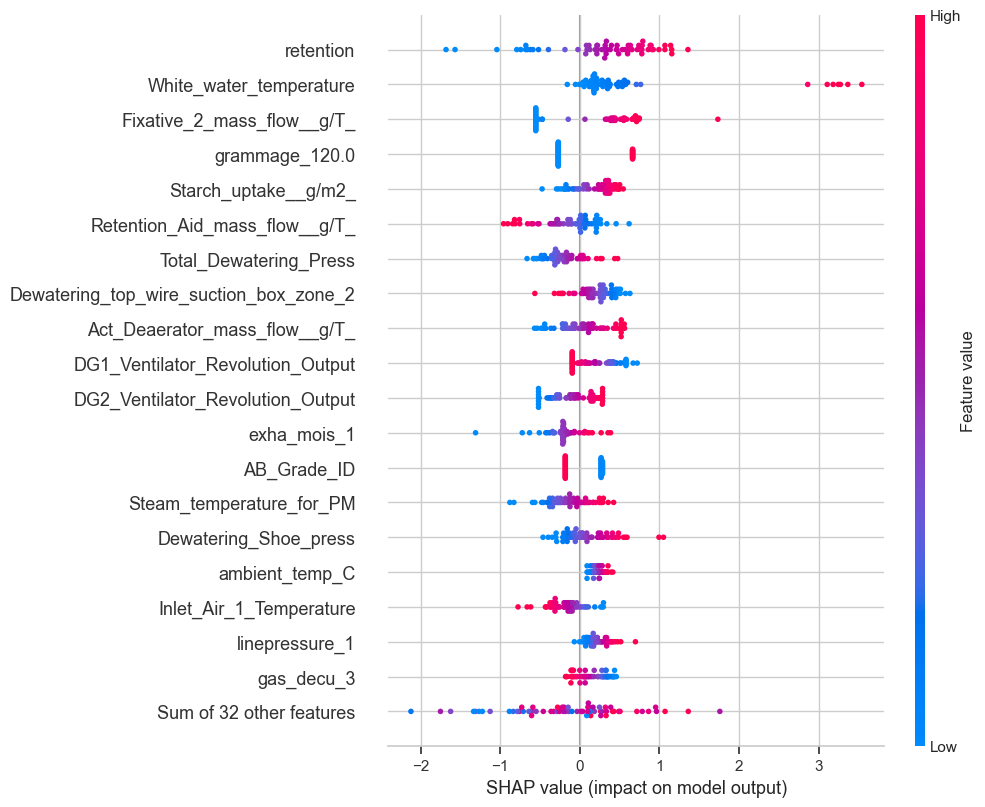

In [33]:
# SHAP summary (beeswarm)
shap.plots.beeswarm(shap_values, max_display=20, show=True)

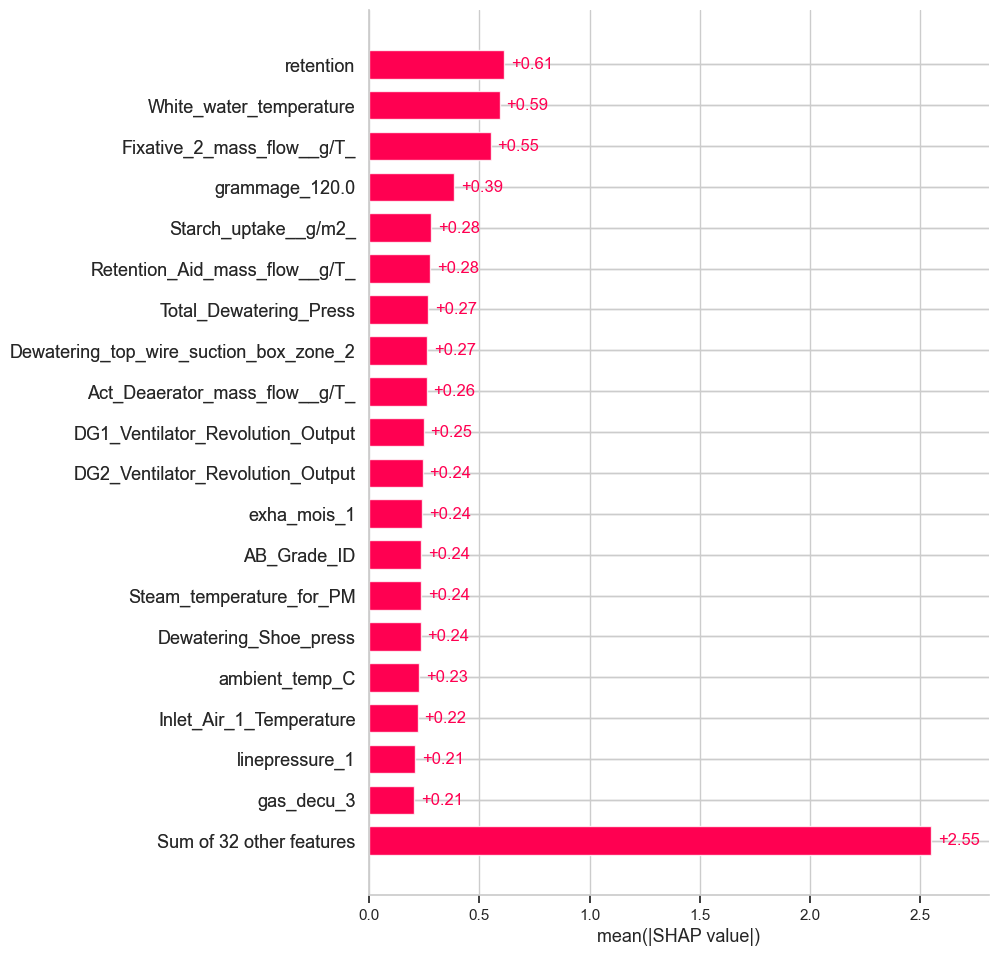

In [34]:
# SHAP bar plot (mean absolute contribution)
shap.plots.bar(shap_values, max_display=20, show=True)

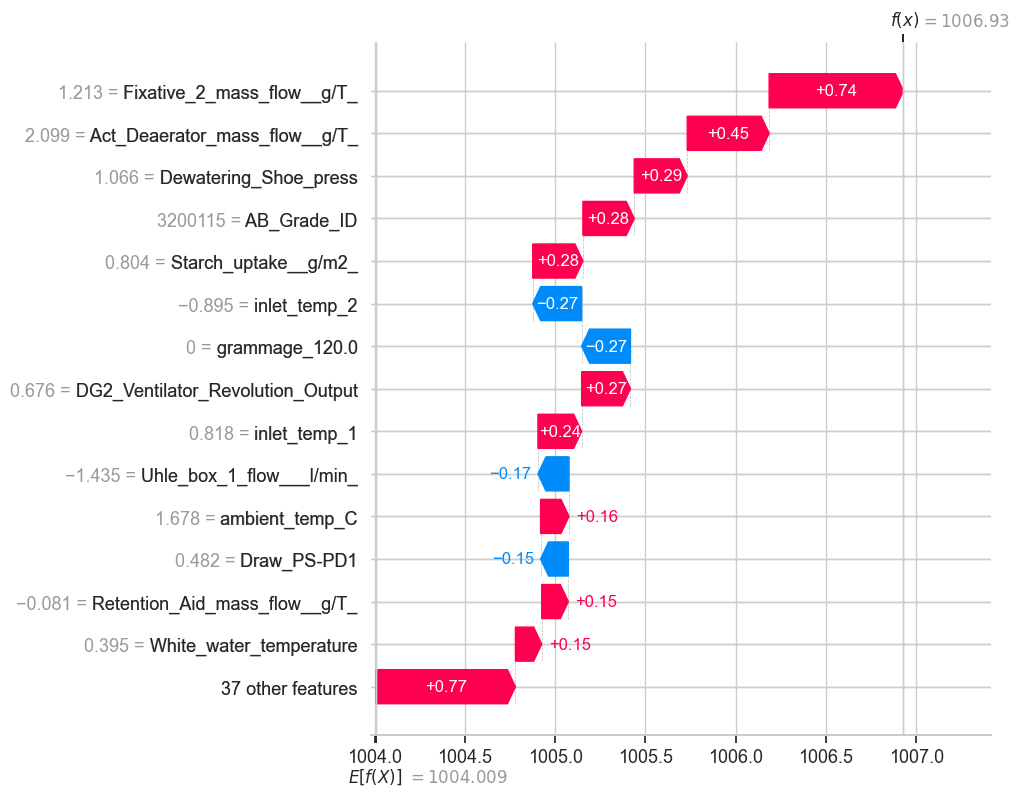

In [35]:
# SHAP waterfall for a single test run
run_idx = 0  # change to inspect different runs
shap.plots.waterfall(shap_values[run_idx], max_display=15, show=True)

## 11. Causal State Estimation (one-step-ahead)

The smoothed level uses future observations (backward pass), which is
optimistic for forecasting. Here we use the **one-step-ahead filtered** level:
for each test run t, the state is predicted from data up to t-1 only —
reflecting what is actually knowable in production.

$\hat{s}_{t|t-1} = E[s_t \mid y_{1:t-1}]$

In [11]:
# One-step-ahead (causal) level on the demeaned test target
# state_est_raw was fit on ytr demeaned; get causal level for test
level_causal_test = state_est_raw.one_step_ahead_level(y_demeaned.iloc[split_run:])

# Smoothed level (uses future) for comparison
level_smoothed_test = level_from_y.iloc[-len(yte_run):]

# Compare the two
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yte_run.index, level_smoothed_test.values, 'o-', ms=3, lw=1.2,
        label='Smoothed level (uses future)')
ax.plot(yte_run.index, level_causal_test.values, 's-', ms=3, lw=1.2,
        label='One-step-ahead level (causal)')
ax.axhline(0, ls='--', color='gray')
ax.set_title(f'{Y_COLUMN} — Smoothed vs Causal Level (test)')
ax.set_ylabel('Level'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

ValueError: Given `endog` does not have an index that extends the index of the model.

In [ ]:
# Combined predictions using each level, evaluated on original scale
y_pred_smoothed = y_test_pred_adj + level_smoothed_test.values
y_pred_causal = y_test_pred_adj + level_causal_test.values

rmse_smooth = np.sqrt(mean_squared_error(yte_run, y_pred_smoothed))
r2_smooth = r2_score(yte_run, y_pred_smoothed)
rmse_causal = np.sqrt(mean_squared_error(yte_run, y_pred_causal))
r2_causal = r2_score(yte_run, y_pred_causal)
rmse_ridge_only = np.sqrt(mean_squared_error(yte_run, y_test_pred_adj + 0))

print('Honest future-state performance:')
print(f'  Ridge + Smoothed level (optimistic): RMSE={rmse_smooth:.2f}, R2={r2_smooth:.4f}')
print(f'  Ridge + Causal level (realistic):    RMSE={rmse_causal:.2f}, R2={r2_causal:.4f}')

# Plot: actual vs both
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yte_run.index, yte_run.values, 'k--', lw=1.5, label='Actual', zorder=10)
ax.plot(yte_run.index, y_pred_smoothed, 'o-', ms=3, lw=1.0, alpha=0.7,
        label=f'Ridge + Smoothed (R2={r2_smooth:.3f})')
ax.plot(yte_run.index, y_pred_causal, 's-', ms=3, lw=1.2,
        label=f'Ridge + Causal (R2={r2_causal:.3f})')
ax.set_title(f'{Y_COLUMN} — Causal vs Smoothed Combined Prediction')
ax.set_ylabel(Y_COLUMN); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()